# Autoregressive TCN 训练

复用统一训练流水线，当前 notebook 只表达模型配置和结果展示。

## 配置

In [1]:
from datetime import datetime
from pathlib import Path
from scripts.experiment import (
    AutoregressiveTCNConfig,
    DataConfig,
    DeviceConfig,
    ExperimentConfig,
    SchedulerConfig,
    TrainingConfig,
)
from scripts.pipeline import (
    run_training_experiment,
    plot_loss,
    model_summary,
    load_model_tier
)

model_tier = load_model_tier('tcn', 'medium')
config = ExperimentConfig(
    data=DataConfig(
        dataset_path=Path("data/processed"),
        tokenizer_path=Path("data/processed/tokenizer.json"),
        output_dir=Path(model_tier["output_path"]),
    ),
    model=AutoregressiveTCNConfig(embedding_dim=model_tier["embedding_dim"],
                                  channels=model_tier["channels"],
                                  kernel_size=model_tier["kernel_size"],
                                  dilations=model_tier["dilations"]),
    training=TrainingConfig(
        batch_size=512,
        num_epochs=50,
        learning_rate=1e-3,
        scheduler=SchedulerConfig(name="cosine", eta_min=1e-6),
    ),
    device=DeviceConfig(mode="formal_cuda"),
)
model_summary(config)

Layer (type:depth-idx)                   Output Shape              Param #
AutoregressiveTCN                        [1, 1, 99]                --
├─Embedding: 1-1                         [1, 1, 128]               12,672
├─ModuleList: 1-2                        --                        --
│    └─Conv1d: 2-1                       [1, 256, 1]               98,560
│    └─Conv1d: 2-2                       [1, 256, 1]               196,864
│    └─Conv1d: 2-3                       [1, 256, 1]               196,864
│    └─Conv1d: 2-4                       [1, 256, 1]               196,864
├─Linear: 1-3                            [1, 1, 128]               32,896
Total params: 734,720
Trainable params: 734,720
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.73
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.94
Estimated Total Size (MB): 2.95


## 训练和结果

In [2]:
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_log_dir = (Path("/root/tf-logs/passmini/training")
                       / config.data.output_dir.relative_to("output") / run_id)
artifacts = run_training_experiment(
    config, tensorboard_log_dir=tensorboard_log_dir, tensorboard_log_interval=100
)
print(f"TensorBoard logs: {tensorboard_log_dir}")

Epoch 23/50 - 训练损失: 2.5736, 验证损失: 2.5748, 耗时: 293.73s
Epoch 24/50 - 训练损失: 2.5730, 验证损失: 2.5741, 耗时: 291.43s
Epoch 25/50 - 训练损失: 2.5724, 验证损失: 2.5736, 耗时: 284.09s
Epoch 26/50 - 训练损失: 2.5718, 验证损失: 2.5729, 耗时: 284.71s
Epoch 27/50 - 训练损失: 2.5712, 验证损失: 2.5725, 耗时: 285.87s
Epoch 28/50 - 训练损失: 2.5707, 验证损失: 2.5719, 耗时: 288.79s
Epoch 29/50 - 训练损失: 2.5701, 验证损失: 2.5715, 耗时: 288.92s
Epoch 30/50 - 训练损失: 2.5695, 验证损失: 2.5708, 耗时: 285.98s
Epoch 31/50 - 训练损失: 2.5690, 验证损失: 2.5706, 耗时: 284.66s
Epoch 32/50 - 训练损失: 2.5685, 验证损失: 2.5701, 耗时: 278.69s
Epoch 33/50 - 训练损失: 2.5680, 验证损失: 2.5695, 耗时: 283.51s
Epoch 34/50 - 训练损失: 2.5675, 验证损失: 2.5693, 耗时: 284.69s
Epoch 35/50 - 训练损失: 2.5670, 验证损失: 2.5687, 耗时: 285.72s
Epoch 36/50 - 训练损失: 2.5665, 验证损失: 2.5684, 耗时: 285.22s
Epoch 37/50 - 训练损失: 2.5661, 验证损失: 2.5678, 耗时: 289.63s
Epoch 38/50 - 训练损失: 2.5657, 验证损失: 2.5674, 耗时: 283.58s
Epoch 39/50 - 训练损失: 2.5653, 验证损失: 2.5671, 耗时: 287.32s
Epoch 40/50 - 训练损失: 2.5649, 验证损失: 2.5669, 耗时: 285.22s
Epoch 41/50 - 训练损失: 2.5645, 

In [3]:
artifacts.history

{'train_loss': [2.6614673219516702,
  2.620085195061147,
  2.608556966304029,
  2.599988227584391,
  2.5954113893472615,
  2.5922488322521318,
  2.589702665963293,
  2.5876303363277176,
  2.5858865372080806,
  2.5843437201666855,
  2.583092211402682,
  2.581954431923208,
  2.5809525135261424,
  2.5800143316303465,
  2.579155803869034,
  2.57833919700313,
  2.5775640571178036,
  2.576841114803125,
  2.57616641536348,
  2.575515690586048,
  2.574856423136927,
  2.574232903898378,
  2.5736151450183207,
  2.572985233186646,
  2.5724112640082017,
  2.57182531571584,
  2.571228414317349,
  2.570661707151425,
  2.5701036286185,
  2.5695421393679037,
  2.5690052473980063,
  2.5684633159955697,
  2.5679643179549436,
  2.5674726391619402,
  2.56698142544828,
  2.566520499452997,
  2.566081153644492,
  2.5656527189054197,
  2.565252519027058,
  2.564874893126446,
  2.564524876996111,
  2.5642003884274,
  2.5639012038720135,
  2.563639324134531,
  2.5634049137280877,
  2.5631982555277335,
  2.5630

Model: tcn
Test loss: 2.5655


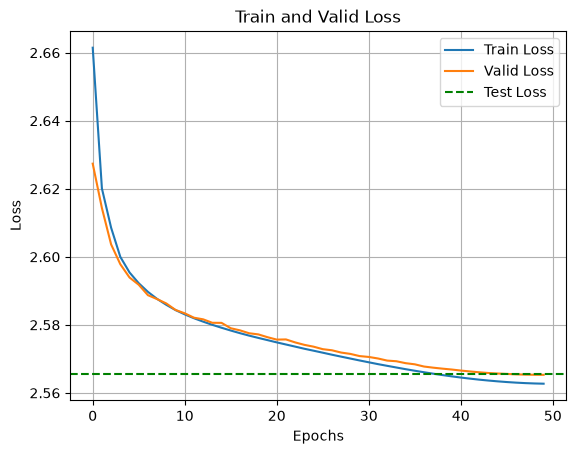

In [4]:
print(f"Model: {config.model.model_type}")
print(f"Test loss: {artifacts.test_loss:.4f}")
plot_loss(artifacts.history, test_loss=artifacts.test_loss, save_path=config.data.output_dir / "loss.png")

In [5]:
artifacts.model.generate(max_length=12)

'fuk0568052nb'